In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, LSTM
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
# Confusion matrix
from sklearn.metrics import confusion_matrix
from keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [22]:
# Load the synthetic data
dataset = pd.read_csv('data.csv')
dataset.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
0,6778,TCP,Streaming,FIN,766738,359903,0,0,0,2,...,9,0.612294,0.097160,0.943965,0.117089,0.051927,0.051801,0.049866,0.052959,0
1,8269,CFDP,Streaming,ACK,402079,917446,0,0,0,3,...,2,0.810122,0.144337,0.879613,0.170300,0.094294,0.099989,0.011208,0.020746,0
2,3498,SCTP,File Transfer,ACK,799133,410319,0,0,1,1,...,1,0.993679,0.029827,0.765519,0.090491,0.048216,0.079222,0.063850,0.023881,0
3,5558,UDP,File Transfer,FIN,198765,965374,0,0,1,1,...,8,0.582741,0.263340,0.887341,0.103336,0.072497,0.099506,0.045185,0.065619,0
4,9586,SCOS-2000,Streaming,ACK,880467,205808,0,0,1,3,...,2,0.928879,0.044424,0.990342,0.190556,0.085182,0.038133,0.025135,0.047181,0


#### Data Preprocessing

In [23]:
#scale numeric data
from sklearn.preprocessing import RobustScaler

def scale_numeric_features(dataframe, cat_cols):
    dataframe = dataframe.copy()
    num_cols = dataframe.drop(columns=cat_cols).columns
    scaler = RobustScaler()
    dataframe[num_cols] = scaler.fit_transform(dataframe[num_cols])
    return dataframe



In [25]:
#Label Wncoding categorical data
from sklearn.preprocessing import LabelEncoder

def label_encode_features(dataframe, cat_cols):
    dataframe = dataframe.copy()
    for col in cat_cols:
        le = LabelEncoder()
        dataframe[col] = le.fit_transform(dataframe[col])
    return dataframe


In [26]:
#One Hot Encoding
import pandas as pd

def one_hot_encode_features(dataframe, onehot_cols):
    dataframe = dataframe.copy()
    dataframe = pd.get_dummies(dataframe, columns=onehot_cols)
    return dataframe


In [27]:
def preprocess_data(dataframe):
    cat_cols = ['protocol_type', 'service', 'flag', 'land', 'logged_in',
                'is_host_login', 'is_guest_login', 'outcome']
    
    onehot_cols = ['protocol_type', 'service', 'flag']
    dataframe = scale_numeric_features(dataframe, cat_cols)
    dataframe = label_encode_features(dataframe, cat_cols)
    dataframe = one_hot_encode_features(dataframe, onehot_cols)

    return dataframe


In [28]:
processed_data = preprocess_data(dataframe=dataset)


In [29]:
# Split data into features and labels
X = processed_data.drop('outcome', axis=1)
y = processed_data['outcome']

In [30]:
# Apply SMOTE for balancing the data
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

In [31]:
# Dimensionality reduction with PCA
pca = PCA(n_components=20)
X_reduced = pca.fit_transform(X_resampled)


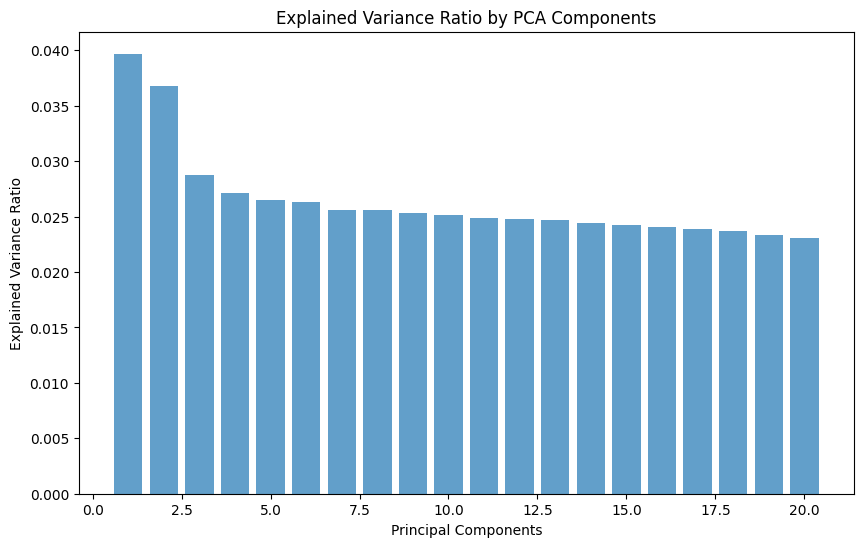

In [32]:
# Visualize explained variance ratio by PCA components
plt.figure(figsize=(10, 6))
plt.bar(range(1, 21), pca.explained_variance_ratio_, alpha=0.7, align='center')
plt.title('Explained Variance Ratio by PCA Components')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.show()

In [33]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_resampled, test_size=0.2, random_state=42)

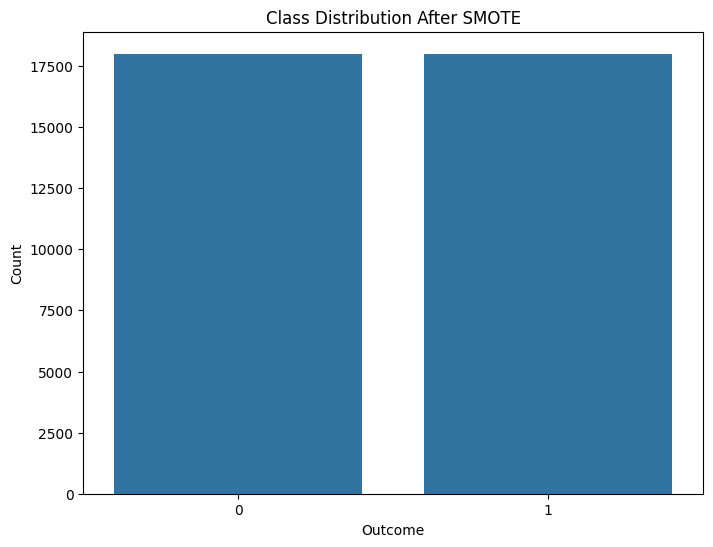

In [34]:
# Visualize class distribution after SMOTE
plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

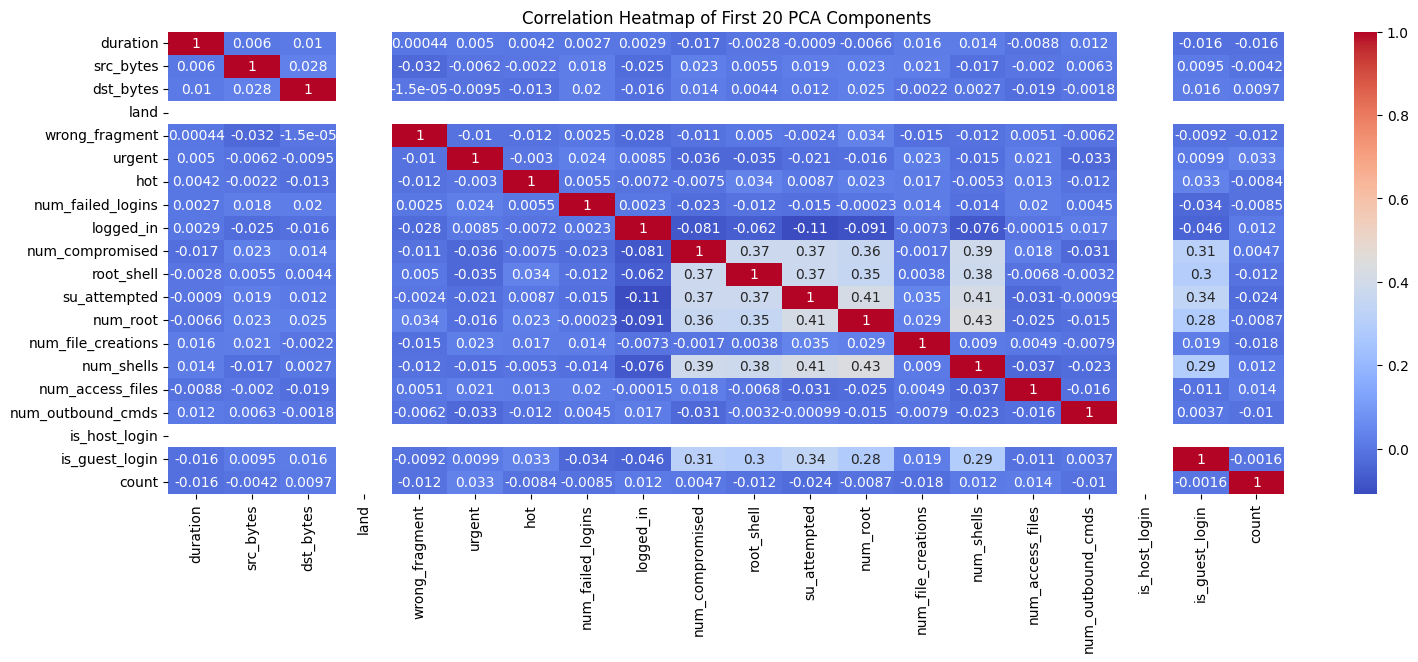

In [41]:
# Visualize correlation heatmap of a subset of features (first 20 features)
plt.figure(figsize=(18, 6))
correlation_matrix = pd.DataFrame(X_resampled).iloc[:, :20].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of First 20 PCA Components')
plt.show()


#### Model Architecture
CNN-LSTM Model Design

Our model architecture combines CNN and LSTM layers to effectively handle the characteristics of network traffic data:

1- Convolutional Layer (Conv1D): Extracts local features from the input data.<br>
2- MaxPooling Layer: Reduces the dimensionality of the feature maps, retaining only the most critical information.<br>
3- LSTM Layers: Captures sequential dependencies in the data, which is essential for identifying patterns in network traffic.<br>
4- Dropout Layers: Prevents overfitting by randomly setting a fraction of input units to zero during training.<br>
5- Dense Layers: Fully connected layers that lead to the final output.<br>

In [42]:
# Reshape data for CNN-LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [43]:
# Define the model
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=64, return_sequences=True))
model.add(LSTM(units=32))
model.add(Dropout(0.2))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\win10\Desktop\New folder\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [45]:
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])
model.save('cnn_lstm_model.h5')

Epoch 1/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9319 - loss: 0.1580 - val_accuracy: 0.9776 - val_loss: 0.0694
Epoch 2/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9739 - loss: 0.0799 - val_accuracy: 0.9585 - val_loss: 0.1224
Epoch 3/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9765 - loss: 0.0731 - val_accuracy: 0.9786 - val_loss: 0.0654
Epoch 4/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9795 - loss: 0.0672 - val_accuracy: 0.9832 - val_loss: 0.0592
Epoch 5/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9799 - loss: 0.0658 - val_accuracy: 0.9851 - val_loss: 0.0516
Epoch 6/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9824 - loss: 0.0585 - val_accuracy: 0.9807 - val_loss: 0.0554
Epoch 7/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9816 - loss: 0.0574 - val_accuracy: 0.9775 - val_loss: 0.0693
Epoch 8/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9841 - loss: 0.0534 - val_accurac


#### Evaluating Model Performance

We evaluate the model's performance using several metrics:<br>

- Accuracy: Measures the overall correctness of the model.<br>
- Precision: Indicates how many of the predicted positive cases were actually positive.<br>
- Recall: Measures the ability of the model to identify positive cases.<br>
- F1 Score: Harmonic mean of precision and recall, providing a single metric that balances both concerns.<br>

#### Visualizing Training Results <br>
I plot the training and validation loss over epochs to visualize the model's learning process <br>
and ensure it is not overfitting. Additionally, confusion matrices and ROC curves are used to<br>
 provide a more detailed assessment of the model's performance.<br>

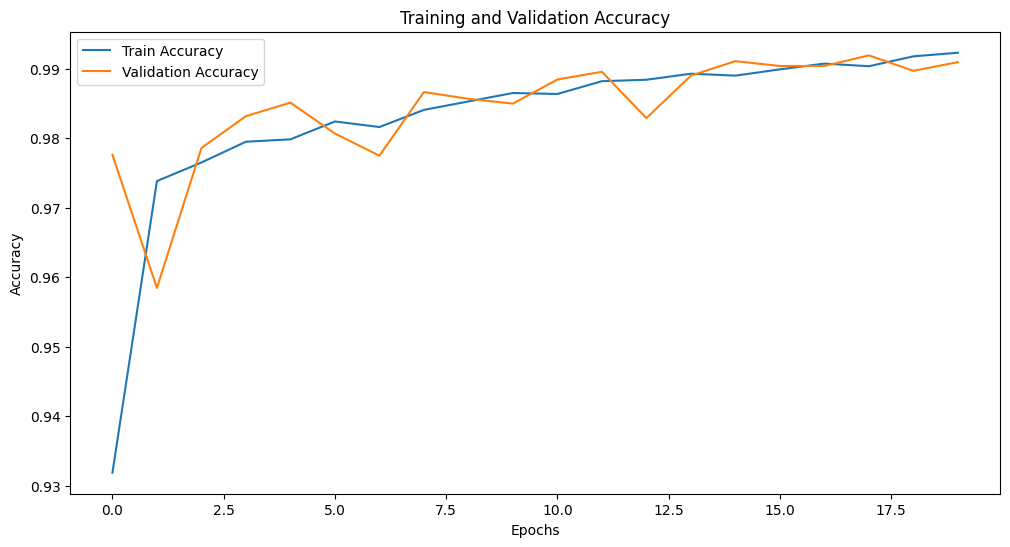

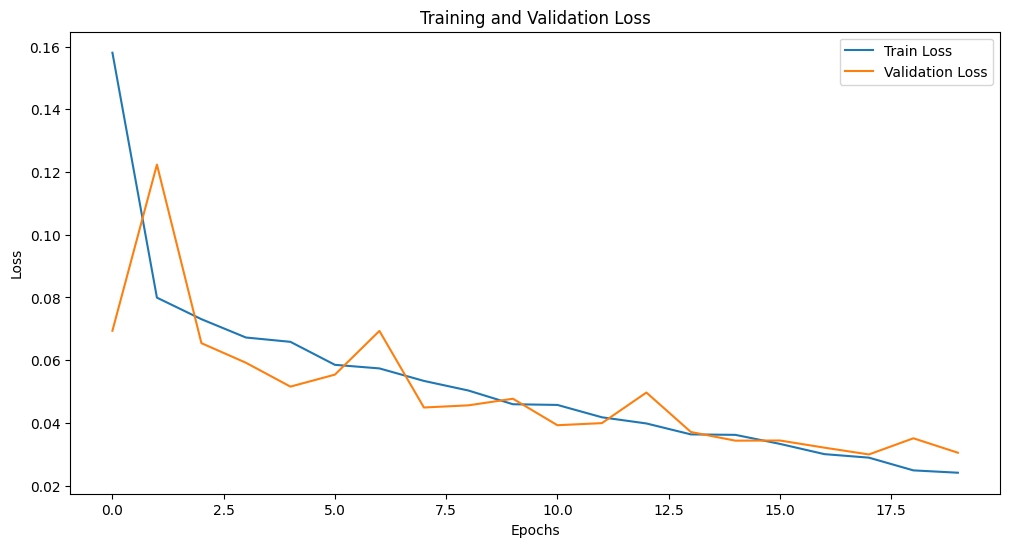

In [46]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [47]:

# Load the model
model = load_model('cnn_lstm_model.h5')

# Make predictions
y_pred = (model.predict(X_test) > 0.5).astype('int')

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy: 0.9919444444444444
Precision: 0.9944180854032934
Recall: 0.9894473757289641
F1 Score: 0.9919265033407573


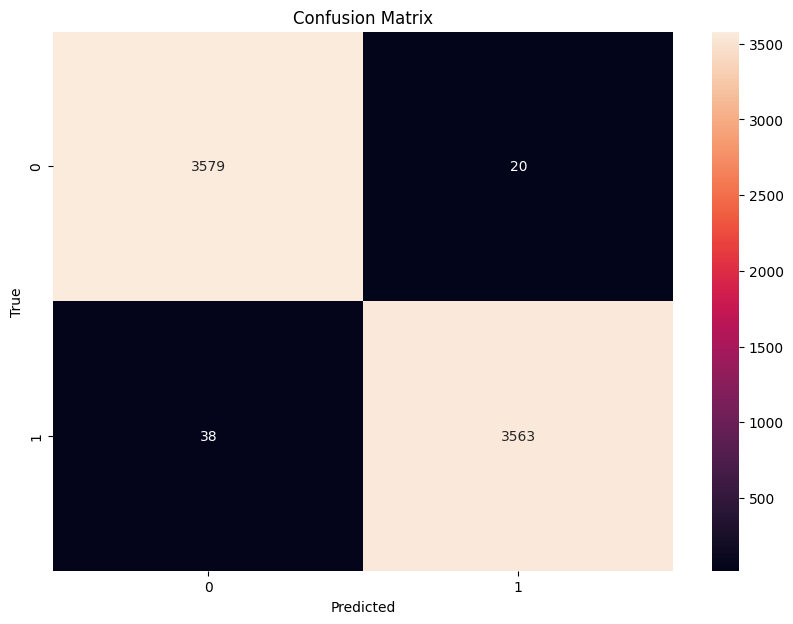

In [50]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
